In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy
from pathlib import Path
import sys

In [53]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

from plotting import set_pubr_theme, pubr_legend


### CNN outer loop results

In [17]:
# Will load csv for each model version as df, combine into one lonf df for evalutaion / plotting

fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Outer_fold_metrics_15px_2026-07-21.csv"

outer_cnn_15px_NO_AWEI = pd.read_csv(fp)

outer_cnn_15px_NO_AWEI.head()


,Unnamed: 0,run_ID,patch_size,test_region,epochs_trained,test_loss,test_accuracy,test_f1,test_precision,test_recall,...,train_loss,train_accuracy,train_f1,train_precision,train_recall,train_auroc,dropout,lr,weight_decay,batch_size
0,0,Test_Har_outer_15px_2026-07-21,15,Hartbeespoort,17,0.286948,0.902067,0.891671,0.980838,0.817365,...,0.134095,0.952603,0.952743,0.946014,0.959569,0.988141,0.106453,0.003865,0.008539,64
1,1,Test_Rod_outer_15px_2026-07-21,15,Rodman,10,0.484522,0.857003,0.866055,0.815199,0.923679,...,0.102237,0.963667,0.963624,0.958738,0.968559,0.993026,0.106453,0.000241,0.000029,64
2,2,Test_Mul_outer_15px_2026-07-21,15,Mula,12,0.642842,0.708977,0.591186,0.923729,0.434696,...,0.077387,0.972799,0.972797,0.971420,0.974177,0.995720,0.397781,0.001212,0.001176,64
3,3,Test_Inl_outer_15px_2026-07-21,15,Inle,8,0.126887,0.954000,0.955556,0.924299,0.989000,...,0.115092,0.959194,0.959107,0.955262,0.962984,0.990927,0.162407,0.001575,0.000004,64
4,4,Test_Vem_outer_15px_2026-07-21,15,Vembanad,9,0.128015,0.956543,0.956303,0.962588,0.950100,...,0.121062,0.956791,0.956669,0.953367,0.959994,0.990258,0.184936,0.004623,0.000005,64


In [20]:
fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Inner_fold_best_state_metrics_15px_2026-07-21.csv"

inner_cnn_15px_NO_AWEI = pd.read_csv(fp)

inner_cnn_15px_NO_AWEI.head()

,Unnamed: 0,run_ID,patch_size,test_region,val_region,train_loss,val_loss,epoch_stopped,val_accuracy,val_f1,...,val_auroc,train_accuracy,train_f1,train_precision,train_recall,train_auroc,dropout,lr,weight_decay,batch_size
0,0,T-Har_V-Rod_15px_2026-07-21,15,Hartbeespoort,Rodman,0.131584,0.300662,14,0.902057,0.906015,...,0.947367,0.953529,0.953467,0.949934,0.957027,0.988241,0.106453,0.003865,0.008539,64
1,1,T-Har_V-Mul_15px_2026-07-21,15,Hartbeespoort,Mula,0.143063,0.317465,8,0.871139,0.862015,...,0.951106,0.950186,0.950591,0.943467,0.957823,0.986619,0.106453,0.003865,0.008539,64
2,2,T-Har_V-Inl_15px_2026-07-21,15,Hartbeespoort,Inle,0.103017,0.091133,29,0.972000,0.972056,...,0.991847,0.963478,0.963505,0.958149,0.968920,0.993081,0.106453,0.003865,0.008539,64
3,3,T-Har_V-Vem_15px_2026-07-21,15,Hartbeespoort,Vembanad,0.125342,0.102003,19,0.969530,0.969667,...,0.993427,0.953435,0.953561,0.946263,0.960972,0.990083,0.106453,0.003865,0.008539,64
4,4,T-Har_V-Val_15px_2026-07-21,15,Hartbeespoort,Valsequillo,0.128104,0.145391,17,0.948039,0.947835,...,0.986383,0.955187,0.955239,0.949525,0.961022,0.989462,0.106453,0.003865,0.008539,64


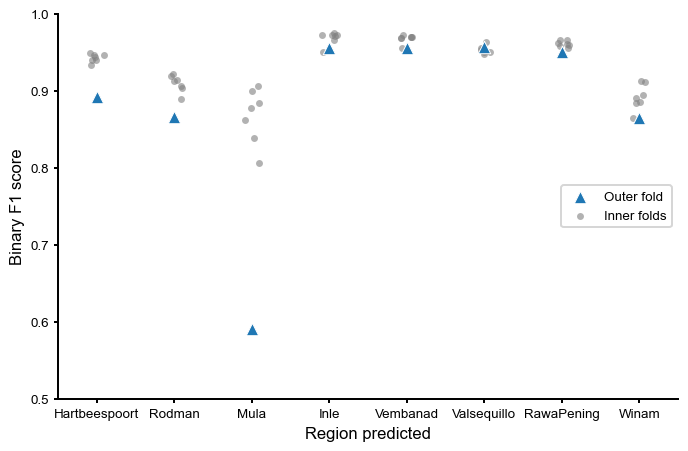

In [80]:
fig, ax = plt.subplots(figsize = (8,5))


set_pubr_theme(legend= "left")

sns.scatterplot(data = outer_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = "test_f1", label = "Outer fold", marker = "^", s = 80, zorder = 2)
sns.stripplot(data = inner_cnn_15px_NO_AWEI, ax = ax, x = "val_region", y = "val_f1", label = "Inner folds", alpha = 0.6, color = "gray", zorder = 1)
ax.set_xlabel("Region predicted")
ax.set_ylabel("Binary F1 score")

ax.legend(loc = "lower right")
ax.set_ylim(bottom = 0.5, top = 1)
 
# Deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
ax.legend(by_label.values(), by_label.keys(), loc = "right", frameon = True)



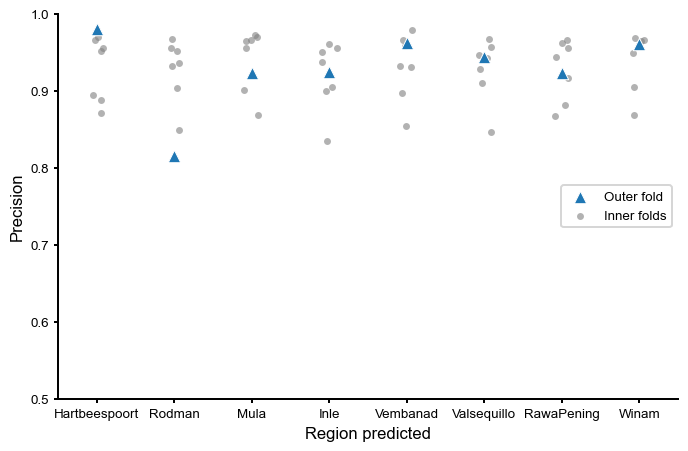

In [79]:
fig, ax = plt.subplots(figsize = (8,5))


set_pubr_theme(legend= "left")

sns.scatterplot(data = outer_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = "test_precision", label = "Outer fold", marker = "^", s = 80, zorder = 2)
sns.stripplot(data = inner_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = "val_precision", label = "Inner folds", alpha = 0.6, color = "gray", zorder = 1)
ax.set_xlabel("Region predicted")
ax.set_ylabel("Precision")

ax.legend(loc = "lower right")
ax.set_ylim(bottom = 0.5, top = 1)
 
# Deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
ax.legend(by_label.values(), by_label.keys(), loc = "right", frameon = True)

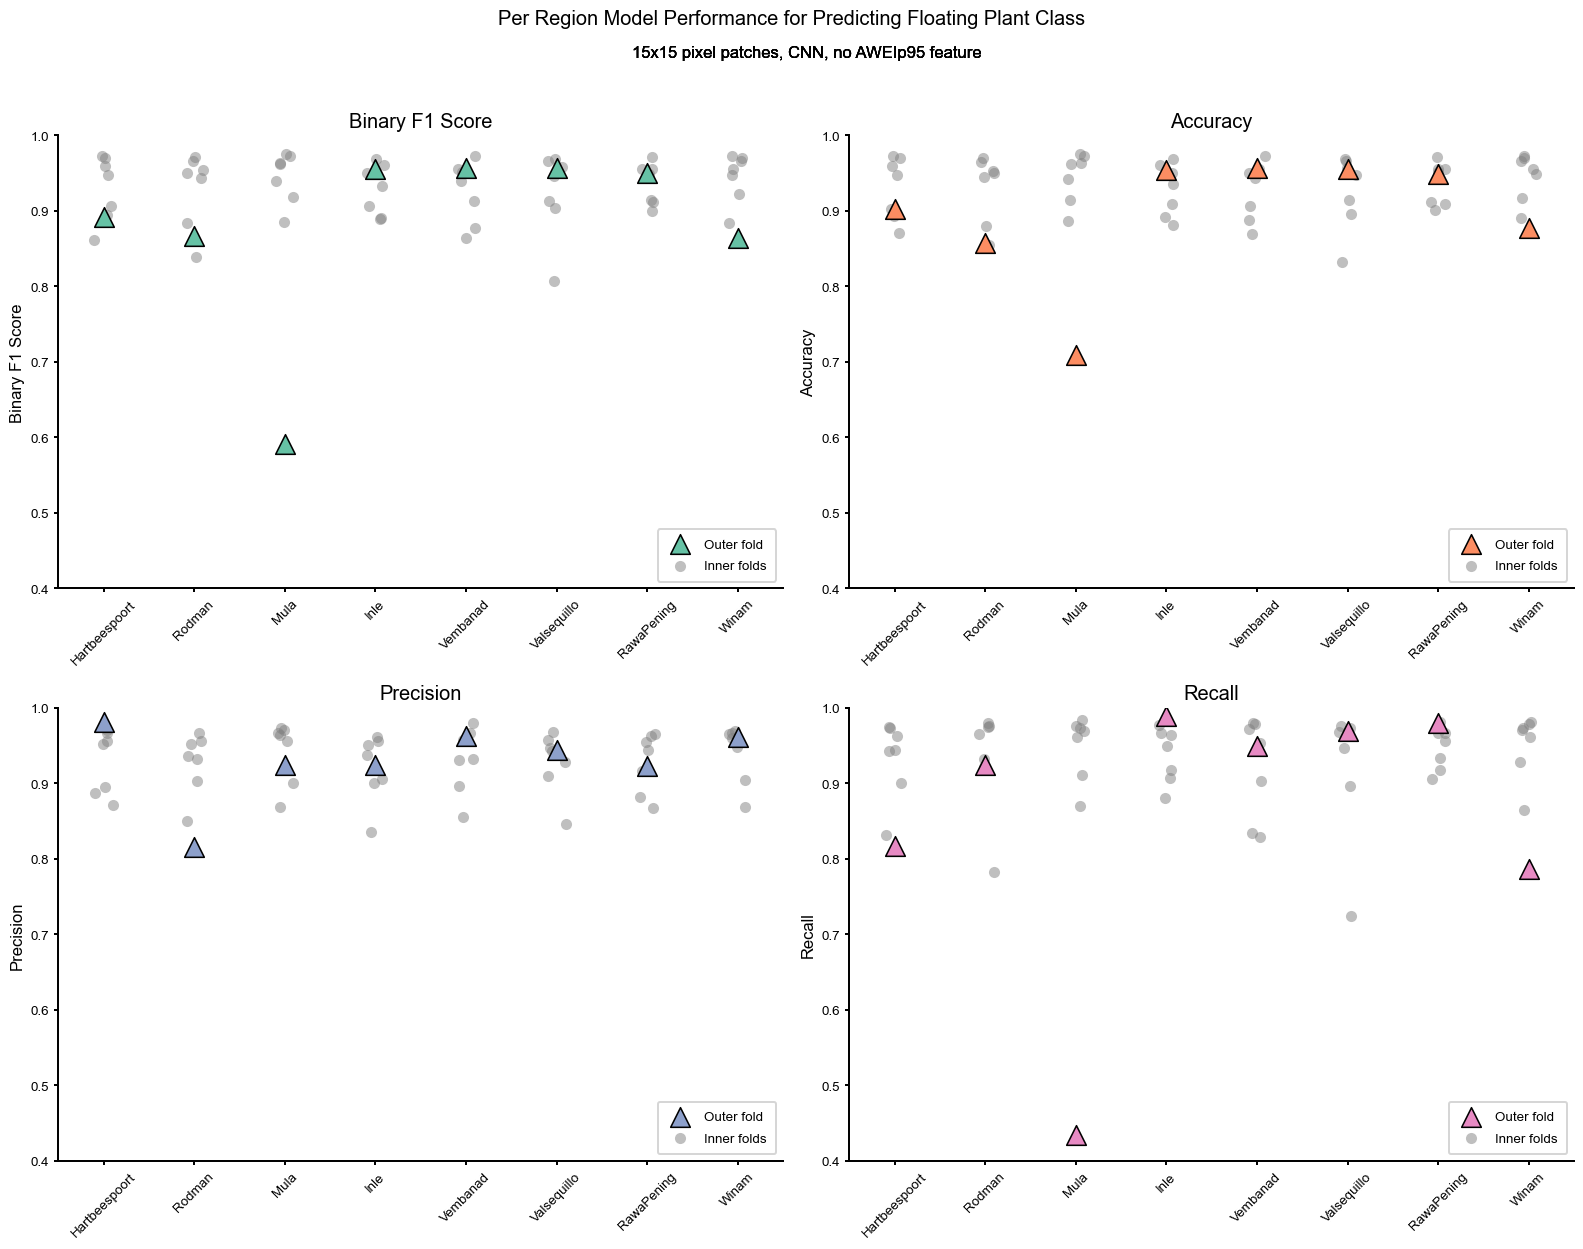

In [130]:

metrics = ["f1", "accuracy","precision","recall"]
metric_name = ["Binary F1 Score", "Accuracy", "Precision", "Recall"]
palette = sns.color_palette("Set2", n_colors = 4)

set_pubr_theme()
fig, axes = plt.subplots(2,2, figsize = (16, 12))
axes = axes.flatten()

for ax, metric, name, color in zip(axes, metrics, metric_name, palette):
    sns.scatterplot(data = outer_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = f"test_{metric}", color = color, edgecolor = "black", label = "Outer fold", marker = "^", s = 200, zorder = 2)
    sns.stripplot(data = inner_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = f"val_{metric}", label = "Inner folds", alpha = 0.5, color = "gray",s = 8, zorder = 1)
    ax.set_xlabel("")
    ax.set_ylabel(f"{name}")
    ax.set_title(f"{name}")
    fig.suptitle("Per Region Model Performance for Predicting Floating Plant Class", y = 1.04)
    fig.text(0.4, 1.0, "15x15 pixel patches, CNN, no AWEIp95 feature")
    ax.legend(loc = "lower right")
    ax.set_ylim(bottom = 0.4, top = 1)
    ax.tick_params(axis="x", rotation=45)
    
    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
    ax.legend(by_label.values(), by_label.keys(), loc = "lower right", frameon = True, borderpad = 0.7, labelspacing = 0.7)
    plt.tight_layout()

### Loss curves

In [ ]:
# Want to be able to save some individually then combine others into a facet plot

# Facets would have inner and outer fold for a given test region. 

# History dict is the sdata source

fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "training_run_history_15px_2026-07-21.csv"

history_cnn_15px_NO_AWEI = pd.read_csv(fp)

print(len(history_cnn_15px_NO_AWEI["run_ID"].unique()))
history_cnn_15px_NO_AWEI.head()




64


,Unnamed: 0,test_region,val_region,run_ID,patch_size,loop,epoch,train_loss,val_loss,val_accuracy,val_f1,val_precision,val_recall,val_auroc,train_accuracy,train_f1,train_precision,train_recall,train_auroc
0,0,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,1,0.341667,0.933920,0.672380,0.748968,0.607425,0.976517,0.804035,0.854313,0.851418,0.864149,0.839058,0.929194
1,1,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,2,0.251553,0.426867,0.833007,0.828385,0.852850,0.805284,0.891305,0.905737,0.905102,0.906609,0.903600,0.961864
2,2,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,3,0.221368,0.527314,0.749265,0.710734,0.840909,0.615460,0.849989,0.920182,0.919851,0.919013,0.920690,0.969599
3,3,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,4,0.195738,0.697393,0.738981,0.677556,0.887480,0.547945,0.856810,0.930417,0.930094,0.929708,0.930480,0.975728
4,4,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,5,0.190710,0.352392,0.887855,0.895862,0.836873,0.963796,0.956258,0.933141,0.932969,0.930659,0.935291,0.976510


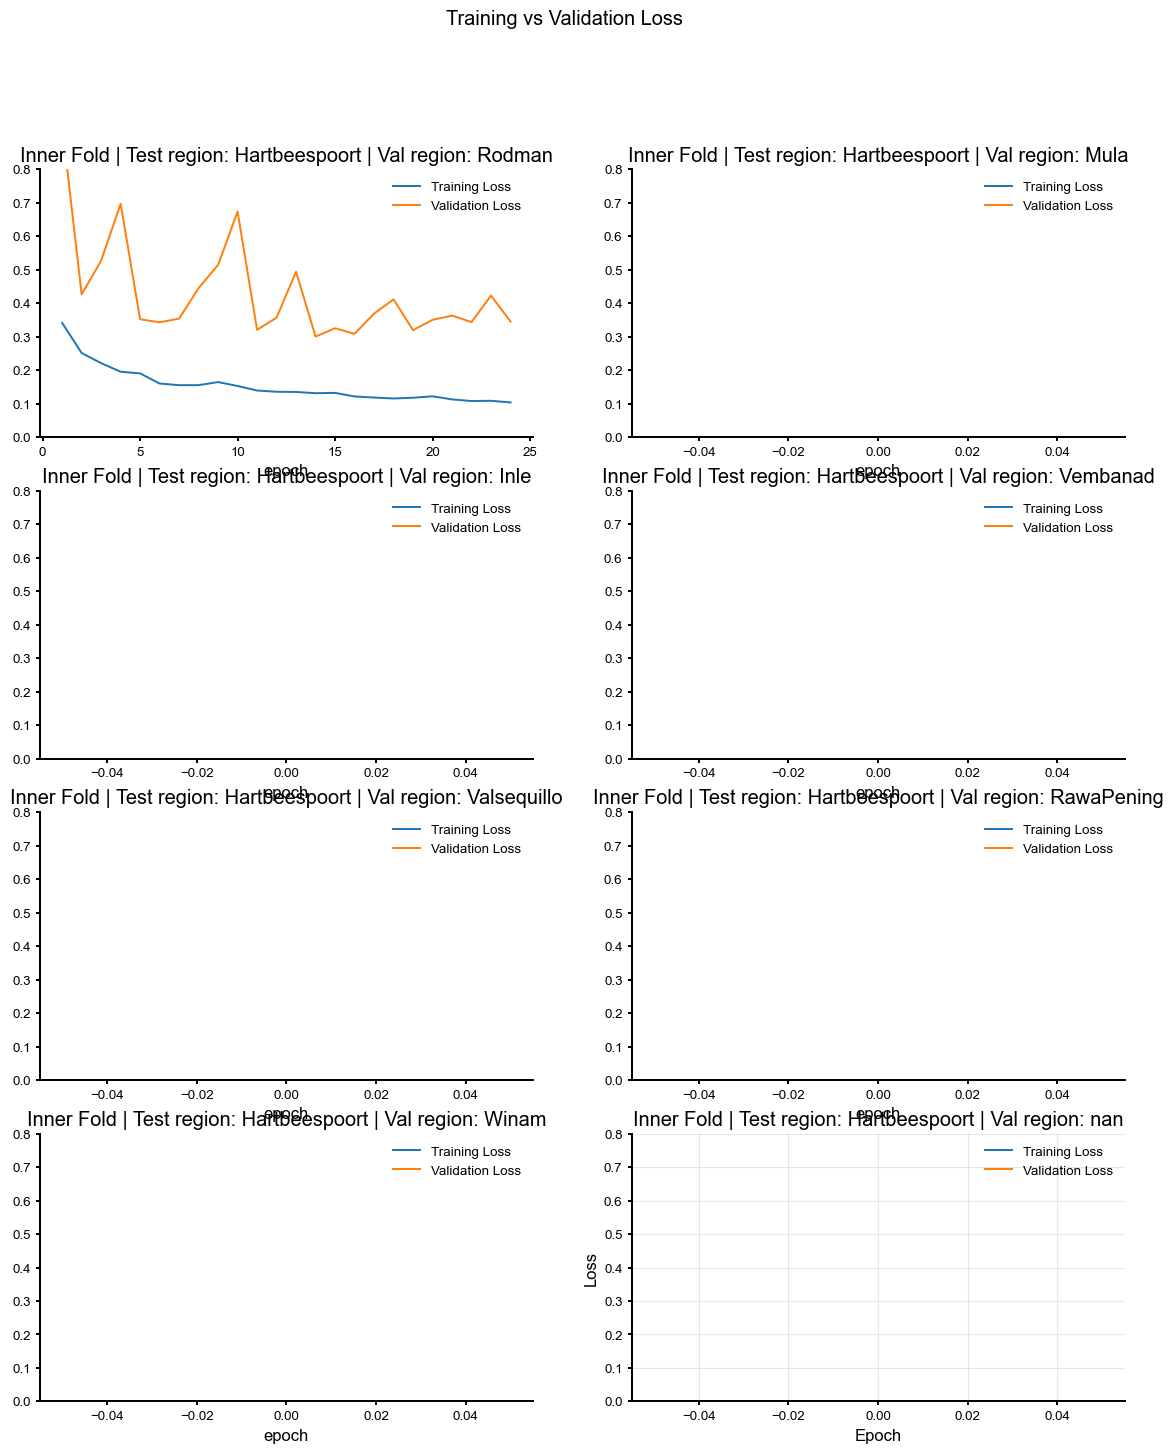

In [173]:
df= history_cnn_15px_NO_AWEI
test_region = "Hartbeespoort"
val_region = "Mula"
fold = None#"inner"
facet = True

test_regions = df["test_region"].unique()

val_regions = df["val_region"].unique()

if not test_region or test_region not in test_regions:
    raise ValueError(f'test_region must be one of {test_regions}')

if fold:

    fig, ax = plt.subplots(figsize = (8,6)) # single figure
    df = df.loc[(df["test_region"] == test_region) & (df["val_region"] == val_region)]

    if fold not in ["inner", "outer"]:
        raise ValueError('fold argument must be either "inner" or "outer"')
    elif fold== "outer":
            
    # plot single plot of the test region train loss
        df.plot(x = "epoch", y = "train_loss", ax = ax, ylim = (0,0.8), label = "Training Loss")
        fig.suptitle(f"Training Loss")
        ax.set_title(f"{fold.title()} Fold | Test region: {test_region}")

    elif fold == "inner" and not facet:
        if not val_region or val_region not in val_regions:
            raise ValueError(f"Please specify a val_region from {val_regions}")
            
        #plot a single fig with the test and val region
        df.plot(x = "epoch", y = "train_loss", ax = ax, ylim = (0,0.8), label = "Training Loss")
        df.plot(x = "epoch", y = "val_loss", ax = ax, label = "Validation Loss")
        fig.suptitle(f"Training vs Validation Loss")
        ax.set_title(f"{fold.title()} Fold | Test region: {test_region} | Val region: {val_region}")
else: 
    # plot facet diagram of the val regions for that test region

    fig, axes = plt.subplots(4,2, figsize = (14, 16))
    axes = axes.flatten()

    for ax, region in zip(axes, val_regions):

        df = df.loc[(df["test_region"] == test_region) & (df["val_region"] == region)]

        df.plot(x = "epoch", y = "train_loss", ax = ax, ylim = (0,0.8), label = "Training Loss")
        df.plot(x = "epoch", y = "val_loss", ax = ax, label = "Validation Loss")
        fig.suptitle(f"Training vs Validation Loss")
        ax.set_title(f"Inner Fold | Test region: {test_region} | Val region: {region}")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def plot_loss_curve_from_df(df, file_path, test_region, val_region = None, fold = None, facet = False):

#     """ Plots training and validation loss curves from the dataframe contructed from concatenated history_dicts"""


    test_regions = df["test_regions"].unique()
    if val_region:
        val_regions = df["val_regions"].unique()

    if not test_region or test_region not in test_regions:

    if fold:
        if fold not in ["inner", "outer"]:
            raise ValueError('fold argument must be either "inner" or "outer"')
    if not fold or fold== "outer":
                
        # plot single plot of the test region train loss
                
    elif fold == "inner" and not facet:
        if not val_region or val_region not in val_regions:
            raise ValueError(f"Please specify a val_region from {val_regions}")
                
        #plot a single fig with the test and val region

    else: 
        # plot facet diagram of the val regions for that test region

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    if history_dict.get("val_loss"):
        plt.suptitle(f"Training vs Validation Loss")
        plt.title(f"{fold} Fold | Test region: {history_dict["test_region"][0]} | Val region: {history_dict["val_region"][0]}")
    else:
        plt.suptitle(f"Training Loss")
        plt.title(f"{fold} Fold | Test region: {history_dict["test_region"][0]}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(Path(file_path), dpi=150)
    plt.show()